In [13]:
#!pip install seaborn
#!pip install scipy

   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   ---------------------------------------- 0.3/37.3 MB ? eta -:--:--
    --------------------------------------- 0.8/37.3 MB 2.8 MB/s eta 0:00:13
   - -------------------------------------- 1.6/37.3 MB 3.2 MB/s eta 0:00:12
   -- ------------------------------------- 2.1/37.3 MB 3.3 MB/s eta 0:00:11
   --- ------------------------------------ 3.1/37.3 MB 3.5 MB/s eta 0:00:10
   ---- ----------------------------------- 3.9/37.3 MB 3.5 MB/s eta 0:00:10
   ----- ---------------------------------- 4.7/37.3 MB 3.6 MB/s eta 0:00:09
   ----- ---------------------------------- 5.5/37.3 MB 3.7 MB/s eta 0:00:09
   ------- -------------------------------- 6.6/37.3 MB 3.8 MB/s eta 0:00:09
   ------- -------------------------------- 7.1/37.3 MB 3.8 MB/s eta 0:00:08
   -------- ------------------------------- 8.1/37.3 MB 3.8 MB/s eta 0:00:08
   --------- ------------------------------ 8.9/37.3 MB 3.8 MB/s eta 0:00:08
   ----------

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set a random seed for reproducibility
np.random.seed(42)

# Create a sample DataFrame with 20 people
n = 20

# Generate realistic data with some built-in correlations
# Heights in centimeters (normally distributed around 170cm with 10cm std)
heights = np.random.normal(170, 10, n)

# Weights in kg (correlated with height but with some randomness)
# Formula creates correlation between height and weight
weights = (heights - 170) * 0.7 + 70 + np.random.normal(0, 5, n)

# Ages in years (18-65, not strongly correlated with height or weight)
ages = np.random.randint(18, 65, n)

# Create the DataFrame
df = pd.DataFrame({
    'height': heights,
    'weight': weights,
    'age': ages
})
# DO NOT CHANGE THE CODE ABOVE
# Run This cell to create your DataFrame

In [4]:
# Display the first 5 rows of the DataFrame
print("Sample DataFrame:")
# Your code here
df.head()

Sample DataFrame:


,height,weight,age
0,174.967142,80.805243,35
1,168.617357,67.903268,43
2,176.476885,74.871461,61
3,185.230299,73.537468,51
4,167.658466,65.639013,27


In [5]:
# Basic statistics of the DataFrame
print("\nBasic Statistics:")
# Your code here HINT: use describe()
df.describe()


Basic Statistics:


,height,weight,age
count,20.000000,20.000000,20.0000
mean,168.287014,67.471034,42.5000
std,9.600284,7.639105,12.0547
min,150.867198,51.318484,25.0000
25%,163.512783,62.310610,32.7500
50%,167.658548,66.771141,40.5000
75%,175.081756,73.870966,51.5000
max,185.792128,80.805243,64.0000


# Correlation Coefficients
![Correlation Coefficients](correlation.png)

| Method | Use Case |
| :--- | :--- |
| **Pearson** | Standard choice for linear relationships between continuous variables. |
| **Spearman** | Use for monotonic relationships, ranked data, or when outliers are present. |
| **Kendall** | Use for ordinal data or when you need a robust rank-based coefficient. |

In [6]:
# Calculate correlation Matrix using df.corr() default setting is "Pearson"
print("\nCorrelation Matrix: (Pearson)")
pearson_matrix = df.corr() 
print(pearson_matrix)


Correlation Matrix: (Pearson)
          height    weight       age
height  1.000000  0.780048  0.194836
weight  0.780048  1.000000  0.022725
age     0.194836  0.022725  1.000000


In [7]:
# Calculate Spearman correlation 
print("\nSpearman Correlation:")
spearman_matrix = df.corr(method='spearman')
print(spearman_matrix)


Spearman Correlation:
          height    weight       age
height  1.000000  0.792481  0.131728
weight  0.792481  1.000000 -0.050433
age     0.131728 -0.050433  1.000000


In [14]:
# Calculate Kendall Tau correlation
print("\nKendall Tau Correlation:")
kendall_matrix = df.corr(method='kendall')
print(kendall_matrix)


Kendall Tau Correlation:
          height    weight       age
height  1.000000  0.631579  0.079578
weight  0.631579  1.000000 -0.037136
age     0.079578 -0.037136  1.000000


In [11]:
# Calculate correlation between specific columns
# Pearson correlation between Height and Weight
correlation = df['height'].corr(df['weight'], method='pearson')
print(f"Pearson correlation: {correlation}")

Pearson correlation: 0.7800476148114798


<Axes: >

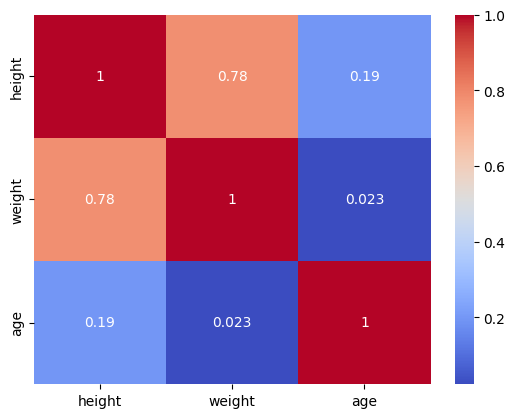

In [16]:
# Visualizing correlations
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

After completing these calculations answer the following questions:
1. Which pair of variables has the strongest positive correlation? What does this mean in practical terms?

2. Which pair of variables has the strongest negative correlation? Explain what this relationship tells us.

3. Is the correlation between height and weight stronger or weaker than you expected? Why might this be the case?

4. Compare the Pearson and Spearman correlation results. Are there any notable differences? What might explain these differences?

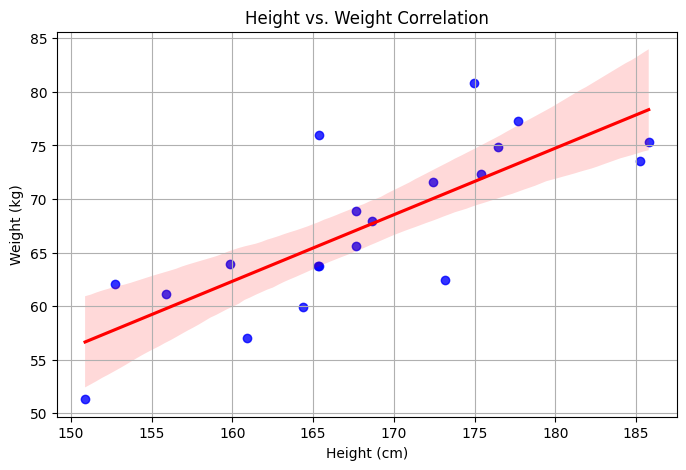

In [15]:
# Create the plot
plt.figure(figsize=(8, 5))
sns.regplot(x='height', y='weight', data=df, color='blue', line_kws={'color': 'red'})

plt.title('Height vs. Weight Correlation')
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.grid(True)
plt.show()